In [1]:
"""ATLAS's Circuit Shaper Simulator"""

import os
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import sympy as sp
from sympy import Eq
from sympy import fraction
from sympy.abc import s
from scipy import signal
from scipy.stats import pearsonr
import random
import Gerador_de_Sinais as gs
from typing import Callable

In [2]:
## Matplotlib Configuration ##

plt.rcParams.update(
    {
        "font.size": 20,  # Tamanho da fonte
        "figure.figsize": (10, 6),  # Tamanho da figura
        "axes.titlesize": 17,  # Título do gráfico
        "axes.labelsize": 15,  # Títulos dos eixos
        "xtick.labelsize": 13,  # Ticks do eixo X
        "ytick.labelsize": 13,  # Ticks do eixo Y
        "legend.fontsize": 13,  # Legendas
        "axes.grid": True,
    }
)

In [3]:
## Functions auxiliares ##


def config_plot_pulso(titles, labelx, ylabel, xlim, ylim=None):
    """
    Configures the visual appearance of a Matplotlib plot for pulse signals.

    Adds title, axis labels, limits, axis lines at zero, and a grid to the plot.

    Args:
        titulo (str): The title of the plot.
        labelx (str): The label for the x-axis.
        ylabel (str): The label for the y-axis.
        xlim (tuple): Tuple containing the minimum and maximum values for the x-axis (x_min, x_max).
        ylim (tuple, optional): Tuple containing the minimum and maximum values for the y-axis (y_min, y_max). Defaults to None.

    Returns:
        None
    """
    plt.title(titles)
    plt.xlabel(labelx)
    plt.ylabel(ylabel)
    plt.xlim(*xlim)
    if ylim:
        plt.ylim(*ylim)
    plt.axhline(0, color="black", linewidth=0.8)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.grid(True)
    plt.tight_layout()


def plot_pulso(
    t,
    y,
    sigma: int = 2,
    show_fig=False,
    only_bandas=True,
):
    # print("Plot pulse")

    # Mean and standard deviation calculation
    y = np.array(y)
    ymed = np.mean(y, axis=0)
    desv_pad = np.std(y, axis=0)

    if not only_bandas:
        # --- 1. Pulse with variations ---
        [plt.plot(t, yi, color="b", linewidth=2) for yi in y]
        config_plot_pulso(
            "Pulso com Variação", "Tempo", "Intensidade do Pulso", (-0.25e-6, 0.5e-6)
        )

        if False:
            plt.show(block=False)
            plt.pause(pause - pause / 2)
            plt.close()
            plt.clf()

        # --- 2. Pulso without variations ---
        plt.plot(t, y[0], color="b", linewidth=2)
        config_plot_pulso(
            "Pulso Sem Variação", "Tempo", "Intensidade do Pulso", (-0.25e-6, 0.5e-6)
        )

        if show_fig:
            plt.show(block=False)
            # plt.pause(pause - pause / 2)
            plt.close()
            plt.clf()

    # # --- 3. Uncertainty Band ---
    # banda_sup = ymed + desv_pad * sigma
    # banda_inf = ymed - desv_pad * sigma

    # plt.plot(y[0], label="Pulso com Valores Nominais", color="b", linewidth=2)
    # plt.plot(ymed, label="Média dos Erros", linestyle="--", color="orange", linewidth=2)
    # plt.plot(banda_sup, label="Banda Superior", linestyle="-.", color="g", linewidth=2)
    # plt.plot(
    #     banda_inf,
    #     label="Banda Inferior",
    #     linestyle="-.",
    #     color="r",
    #     linewidth=2,
    # )
    # plt.fill_between(
    #     range(len(banda_sup)), banda_sup, banda_inf, color="gray", alpha=0.5
    # )

    # config_plot_pulso(
    #     "Bandas de Incerteza", "Tempo", "Intensidade Pulso", (-0.1, 10), (-0.2, 1.25)
    # )
    # plt.legend()

    # if show_fig:
    #     plt.show(block=False)

    #     plt.close("all")
    #     plt.clf()

In [4]:
# Constantes #
t1 = np.arange(0, 400) * 25 * 10**-9  # sinal discreto
# t1: np.linspace(0, 400) # para sinal continuo

xlabels = ["C0", "Ca", "Cb", "Cc", "La", "Lb", "Lc", "RL"]
pause = 1

# Constantes da iteração
qntd_canais = 10  # qntd de listas
amostras_por_leitura = 100  # tamanho da lista
qntd_leitura_por_canal = 100  # usado para as leituras e medias
seed = 42  # fator aleatorio reprodutivel

ckt_parameters_error = (  # dois ultimos são tau1 e tau2
    np.array([10, 1, 1, 1, 2, 2, 2, 0.10, 0, 0], dtype=float)
) / 100

In [5]:
# Sinais Originais #
s_originais = {}  # s_originais
count = 0  # para modificar os sinais entre si

for canais in range(qntd_canais):
    s_originais[f"canal_{canais}"] = []

    for amostra in range(qntd_leitura_por_canal):
        s_originais[f"canal_{canais}"].append(
            gs.original_signal_generator(amostras_por_leitura, seed=seed + count)
        )
        count += 1

Text(0, 0.5, 'Amplitude')

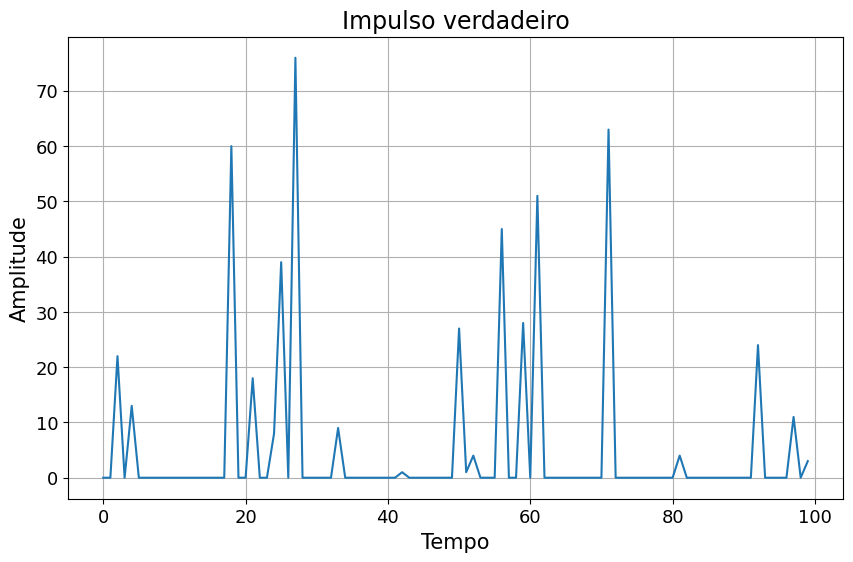

In [6]:
plt.plot(s_originais["canal_0"][0])
plt.title("Impulso verdadeiro")
plt.xlabel("Tempo")
plt.ylabel("Amplitude")

# Olhando ckt_parameters

In [ ]:
# def ckt_parameters_0
def ckt_parameters_old():
    # print("ckt_parameters")

    ## Definition of constants ##
    tau_1, tau_2, Vo, Vi = sp.symbols("tau_1 tau_2 Vo Vi")
    CC0, C1, C2, C3 = sp.symbols("CC0 C1 C2 C3")
    RL = sp.symbols("RL")
    L1, L2, L3 = sp.symbols("L1 L2 L3")
    I1, I2, I3, I4 = sp.symbols("I1 I2 I3 I4")

    # Ckt components in order
    Cord = [CC0, C1, C2, C3, L1, L2, L3, RL, tau_1, tau_2]

    # Nominal values (old values) of Cord elements in order
    Cval = [
        100e-9,  # CC0
        120e-12,  # Ca = C1
        130e-12,  # Cb = C3 + C2
        83e-12,  # Cc = C5 + C4
        2.48e-6,  # La = L1 + L2
        1.6e-6,  # Lb = L3 + L4
        0.78e-6,  # Lc = L5 + L6
        138.8338,  # RL = (R1 + R2) //  R3
        6.5798e-09,  # tau_1
        3.1046e-09,  # tau_2
    ]
    # Ckt equations
    eqn1 = Eq(I1 / (CC0 * s) + (I1 - I2) / (C1 * s), Vi)
    eqn2 = Eq((I2 - I3) / (C2 * s) - (I1 - I2) / (C1 * s) + L1 * s * I2, 0)
    eqn3 = Eq((I3 - I4) / (C3 * s) - (I2 - I3) / (C2 * s) + L2 * s * I3, 0)
    eqn4 = Eq(I4 * RL - (I3 - I4) / (C3 * s) + L3 * s * I4, 0)
    eqn5 = Eq(I4 * RL, Vo)

    eqns = [eqn1, eqn2, eqn3, eqn4, eqn5]

    # Solver
    Sol = sp.solve(eqns, (I1, I2, I3, I4, Vo))
    si6 = Sol[I4]

    # PMT
    PMT = (1 / tau_1 - 1 / tau_2) / (
        s**2 + (1 / tau_1 + 1 / tau_2) * s + 1 / tau_1 / tau_2
    )

    # I_out without V_in
    h = RL * si6 / Vi

    # Final transfer function
    H1 = h * PMT

    return H1, Cord, Cval

In [20]:
# def ckt_parameters
def ckt_parameters(pmt: bool = False):

    ## Definition of constants ##
    tau_1, tau_2, Vo, Vi = sp.symbols("tau_1 tau_2 Vo Vi")
    CC0, C1, C2, C3, C4 = sp.symbols("CC0 C1 C2 C3 C4")
    Ra, Rb, Rc = sp.symbols("Ra Rb Rc")
    L1, L2, L3 = sp.symbols("L1 L2 L3")
    I1, I2, I3, I4, I5, I6 = sp.symbols("I1 I2 I3 I4 I5 I6")

    # Ckt components in order
    Cord = [CC0, C1, C2, C3, C4, L1, L2, L3, Ra, Rb, Rc]  # new
    Cval = [  # new
        101e-9,  # CC0
        33e-12,  # C1
        146e-12,  # C2
        102e-12,  # C3
        6.8e-12,  # C4
        2.48e-6,  # L1
        1.6e-6,  # L2
        0.78e-6,  # L3
        1.5e3,  # Ra
        62.9,  # Rb
        62.9,  # Rc
    ]

    # Ckt equations new
    eqn1 = Eq(I1 / CC0 / s + 1 / C1 / s * (I1 - I2), Vi)
    eqn2 = Eq(1 / C1 / s * (I2 - I1) + s * L1 * I2 + 1 / C2 / s * (I2 - I3), 0)
    eqn3 = Eq(1 / C2 / s * (I3 - I2) + s * L2 * I3 + 1 / C3 / s * (I3 - I4), 0)
    eqn4 = Eq(1 / C3 / s * (I4 - I3) + s * L3 * I4 + 1 / C4 / s * (I4 - I5), 0)
    eqn5 = Eq(1 / C4 / s * (I5 - I4) + (I5 - I6) * Ra, 0)
    eqn6 = Eq(Ra * (I6 - I5) + Rb * I6 + Rc * I6, 0)
    eqn7 = Eq(I6 * (Rb + Rc), Vo)
    RL = Rb + Rc

    # Solver
    eqns = [eqn1, eqn2, eqn3, eqn4, eqn5, eqn6, eqn7]
    Sol = sp.solve(eqns, [I1, I2, I3, I4, I5, I6, Vo])

    si6 = Sol[I6]

    # PMT
    PMT = (1 / tau_2 - 1 / tau_1) / (
        s**2 + (1 / tau_2 + 1 / tau_1) * s + 1 / tau_2 / tau_1
    )

    # I_out without V_in
    h = RL * si6 / Vi

    # Final transfer function
    if pmt:
        H1 = h * PMT
    else:
        H1 = h

    return H1, Cord, Cval

# Olhando MC_Iteration

In [11]:
def MC_iteration(
    iterations,
    erro,
    components,
    nominal_values,
    FT,
    t,
    seed: int | None = None,
):
    """
    iter = 0 represents pure/error-free signal value
    MonteCarlo[0] = actual/error-free signal value

    FT: Transfer Function
    t1: time vector
    iterations: int
        number of iterations
    erro: percentage error of circuit components
    nominal_values: nominal values of circuit components

     seed: int | None
        Semente opcional para reprodutibilidade.
    """
    # print("Monte Carlo iteration")

    # Store all the poles of the iterations
    all_poles = []

    # Store the values ​​with error of each iteration
    MonteCarlo = []

    # Store all the FPs added of each iteration # list of all the graphs added with errors
    y_out = []

    # Helper to store the values ​​of y
    y1 = []

    # Seed para reprodutibilidade
    rng = random.Random(seed)

    for iter in range(iterations):

        # Random values; # error range; maximum error from -e% to +e%
        xa = []  # FP function of the summed iteration
        new_Cval = []  # List of components with changed values

        # Changing element values ​​without changing tau1 and tau2
        new_Cval = [
            (
                value * (rng.gauss(0, erro[idx])) + value
                if iter != 0 and idx < len(nominal_values) - 2
                else value
            )
            for idx, value in enumerate(nominal_values)
        ]

        # Saving component variations
        MonteCarlo.append(new_Cval[:-2])

        H = FT
        for variavel, v in zip(components, new_Cval):
            H = H.subs(variavel, v)

        # Separating numerator from denominator
        N_H, D_H = fraction(H)

        """RESIDUOS E POLOS"""

        coefs_num = []  # reset variable
        coefs_den = []  # reset variable

        coefs_num = sp.Poly(N_H, s).all_coeffs()  # get coefs
        coefs_den = sp.Poly(D_H, s).all_coeffs()  # get coefs

        # Frações parciais
        residuos, polos, b0 = [], [], []
        residuos, polos, b0 = signal.residue(coefs_num, coefs_den)

        # Handle direct polynomial term `b0` returned by residue().
        # `b0` is a polynomial in `s` (direct terms). Its inverse Laplace
        # is a combination of derivatives of delta(t) (impulses at t=0).
        # Approximate these contributions as an impulse at the first sample
        # (this is a discrete-time approximation suitable for convolution with
        # sampled signals). We add this as an extra time-domain term.
        if b0 is not None and len(b0) > 0:
            try:
                b_arr = np.atleast_1d(b0)
            except Exception:
                b_arr = np.array([float(b0)])

            if b_arr.size > 0:
                direct_impulse = np.zeros_like(t)
                # Use the constant term (lowest power) of the polynomial as the
                # impulse amplitude. For b(s) = b_n s^n + ... + b_0, b_0 is b_arr[-1].
                direct_impulse[0] = float(b_arr[-1])
                # Append to the list of terms to be summed into the time response
                xa.append(direct_impulse)

        # Saving all poles
        all_poles.append(polos)

        # Residual correction (removing the img part 0j from the real residuals)
        for polo1, residuo1 in zip(polos, residuos):
            if polo1.imag == 0:
                residuo1 = residuo1.real

        """LAPLACE INVERSA E GRAFICOS"""

        for enum, (polo, residuo) in enumerate(zip(polos, residuos)):

            # Check if the imaginary part is zero
            if polo.imag == 0:
                "EXPONENCIAIS"

                # Removing the img part (0j) of the real residues
                A = residuo.real
                d = polo.real
                x = A * np.exp(d * t)

                xa.append(x)

            else:
                "SENOS E COSSENOS"

                pol_1 = polos[enum - 1]  # conjugate

                if polo != pol_1 and polo != np.conjugate(pol_1):

                    a1 = polo.real
                    b1 = abs(polo.imag)

                    Mod = abs(residuos[enum])  # Modulo
                    fase = np.angle(residuos[enum])  # fase in rad

                    # FP term
                    x = 2 * Mod * np.exp(a1 * t) * np.cos(b1 * t + fase)

                    xa.append(x)

        "SUMMING THE TERMS"

        if iter != 0:
            y1 = sum(xa).real / maxs
            y_out.append(y1)

        else:
            sinal0 = sum(xa).real
            maxs = np.max(np.abs(sinal0))
            y1 = sinal0 / maxs  # largest module/ normalize
            y_out.append(y1)

    return y_out  # , np.array(MonteCarlo).T, all_poles

In [ ]:
# Modo: try1


FT, component, component_values = ckt_parameters()  # type: ignore[operator]

ckt_parameters_error = (  # dois ultimos são tau1 e tau2
    np.array([10, 1, 1, 1, 2, 2, 2, 0.10, 0, 0], dtype=float)
) / 100

iterations = 1
erro = ckt_parameters_error
components = component
nominal_values = component_values
t = np.arange(0, 400) * 25e-9
seed = 42


all_poles = []

# Store the values ​​with error of each iteration
MonteCarlo = []

# Store all the FPs added of each iteration # list of all the graphs added with errors
y_out = []

# Helper to store the values ​​of y
y1 = []

# Seed para reprodutibilidade
rng = random.Random(seed)

for iter in range(iterations):

    # Random values; # error range; maximum error from -e% to +e%
    xa = []  # FP function of the summed iteration
    new_Cval = []  # List of components with changed values

    # Changing element values ​​without changing tau1 and tau2
    new_Cval = [
        (
            value * (rng.gauss(0, erro[idx])) + value
            if iter != 0 and idx < len(nominal_values) - 2
            else value
        )
        for idx, value in enumerate(nominal_values)
    ]

    H = FT
    for variavel, v in zip(components, new_Cval):
        H = H.subs(variavel, v)

    # Separating numerator from denominator
    N_H, D_H = fraction(H)

    """RESIDUOS E POLOS"""

    coefs_num = []  # reset variable
    coefs_den = []  # reset variable

    coefs_num = sp.Poly(N_H, s).all_coeffs()  # get coefs
    coefs_den = sp.Poly(D_H, s).all_coeffs()  # get coefs

    # Frações parciais
    residuos, polos, b0 = [], [], []
    residuos, polos, b0 = signal.residue(coefs_num, coefs_den)

    # Handle direct polynomial term `b0` returned by residue().
    # `b0` is a polynomial in `s` (direct terms). Its inverse Laplace
    # is a combination of derivatives of delta(t) (impulses at t=0).
    # Approximate these contributions as an impulse at the first sample
    # (this is a discrete-time approximation suitable for convolution with
    # sampled signals). We add this as an extra time-domain term.
    if b0 is not None and len(b0) > 0:
        try:
            b_arr = np.atleast_1d(b0)
        except Exception:
            b_arr = np.array([float(b0)])

        if b_arr.size > 0:
            direct_impulse = np.zeros_like(t)
            # Use the constant term (lowest power) of the polynomial as the
            # impulse amplitude. For b(s) = b_n s^n + ... + b_0, b_0 is b_arr[-1].
            direct_impulse[0] = float(b_arr[-1])
            # Append to the list of terms to be summed into the time response
            xa.append(direct_impulse)

    # Saving all poles
    all_poles.append(polos)

    # Residual correction (removing the img part 0j from the real residuals)
    for polo1, residuo1 in zip(polos, residuos):
        if polo1.imag == 0:
            residuo1 = residuo1.real

    """LAPLACE INVERSA E GRAFICOS"""

    for enum, (polo, residuo) in enumerate(zip(polos, residuos)):

        # Check if the imaginary part is zero
        if polo.imag == 0:
            "EXPONENCIAIS"

            # Removing the img part (0j) of the real residues
            A = residuo.real
            d = polo.real
            x = A * np.exp(d * t)

            xa.append(x)

        else:
            "SENOS E COSSENOS"

            pol_1 = polos[enum - 1]  # conjugate

            if polo != pol_1 and polo != np.conjugate(pol_1):

                a1 = polo.real
                b1 = abs(polo.imag)

                Mod = abs(residuos[enum])  # Modulo
                fase = np.angle(residuos[enum])  # fase in rad

                # FP term
                x = 2 * Mod * np.exp(a1 * t) * np.cos(b1 * t + fase)

                xa.append(x)

    "SUMMING THE TERMS"

    sinal0 = sum(xa).real
    pico = np.max(abs(sinal0))
    vale = np.min(sinal0)
    # se pico=1, o undershoot é de 0.7%
    y_out.append(sinal0 / pico)  # largest module/normalize

y_out = np.array(y_out)

"""
Quando eu retiro a normalizaçao, o undershoot do pulso sem variaçao vai a ~0.7%.
Como os valores de picos das ondas é por volta de ~0.1, ao dividir o vale pelo pico, o undershoot sobra pra ~7%.
"""

pulso_em_estudo = y_out[0][:12]
plt.plot(pulso_em_estudo)
undershoot = 100.0 * vale / pico
print(f"% do undershoot: {undershoot:.4f}%")
# try1

% do undershoot: -3.0859%
% do undershoot_norm: -3.0859%


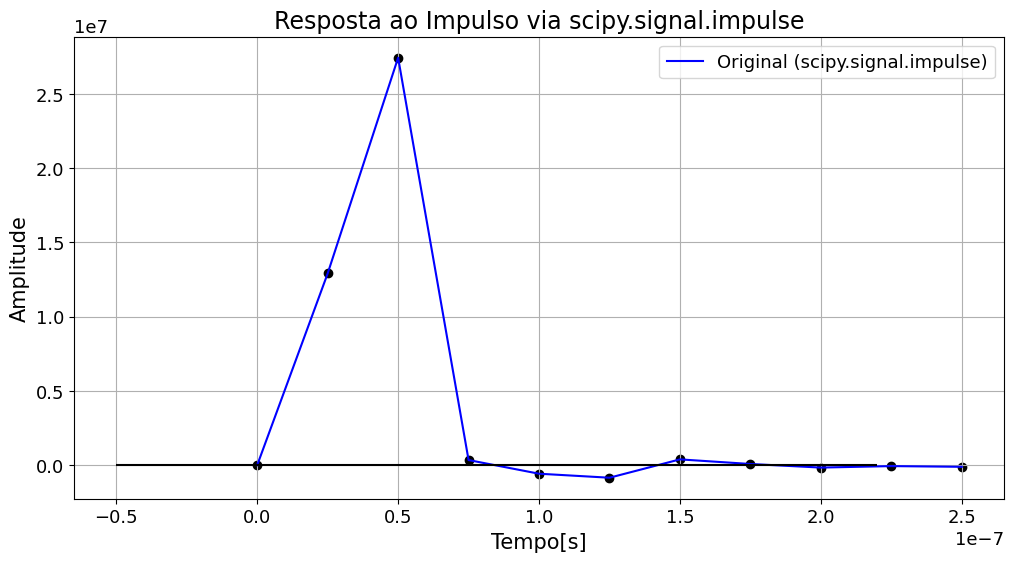

In [22]:
# Modo: try2
# exemplo com scipy.signal.impulse
FT, component, nominal_values = ckt_parameters()
inverter = False

iterations = 1
erro = ckt_parameters_error
seed = 42
T = np.arange(0, 1000) * 25e-9

rng = random.Random(seed)

for iter in range(iterations):

    new_Cval = [
        (
            value * (rng.gauss(0, erro[idx])) + value
            if iter != 0 and idx < len(nominal_values) - 2
            else value
        )
        for idx, value in enumerate(nominal_values)
    ]

    # Substituir variaveis
    subs_dict = dict(zip(component, new_Cval))
    H = FT.subs(subs_dict)

    # dividir numerador e denominador
    N_H, D_H = fraction(H)

    # pegar coeficientes
    coefs_num = sp.Poly(N_H, s).all_coeffs()
    coefs_den = sp.Poly(D_H, s).all_coeffs()

    # Converter para float
    coefs_num = [float(c) for c in coefs_num]
    coefs_den = [float(c) for c in coefs_den]

    # Função de transferência
    system = signal.TransferFunction(coefs_num, coefs_den)

    # Resposta ao impulso
    T_resp, y_impulse = signal.impulse(system=system, T=T)
    if inverter:
        y_impulse = -y_impulse

    # Normalizar
    pico = np.max(y_impulse)
    # print(f'{pico=}')
    y_norm_peak = y_impulse / pico if pico != 0 else y_impulse
    undershoot_norm = 100.0 * np.min(y_norm_peak)

    # Plot
    limite = 11
    plt.figure(figsize=(12, 6))
    plt.plot(
        T_resp[:limite],
        y_impulse[:limite],
        label="Original (scipy.signal.impulse)",
        color="b",
    )
    plt.scatter(T_resp[:limite], y_impulse[:limite], color="black")

    # plt.plot(
    #     T_resp[:limite],
    #     y_norm_peak[:limite],
    #     label="Normalizado por max(y)",
    #     color="darkorange",
    # )
    # plt.scatter(T_resp[:limite], y_norm_peak[:limite], linewidth=2, color="darkgreen")

    plt.vlines(
        x=T_resp[:7],
        ymin=np.min(y_norm_peak) * 1.25,
        ymax=1.1,
        colors="r",
        linestyles=":",
        linewidth=1.5,
    )

    plt.title("Resposta ao Impulso via scipy.signal.impulse")
    plt.xlabel("Tempo[s]")
    plt.ylabel("Amplitude")
    plt.hlines(0, -0.5e-7, 2.2e-7, colors="black")
    plt.vlines(0, 0, 1.1, colors="black")
    plt.legend()


pico = np.max(abs(y_norm_peak))
vale = np.min(y_norm_peak)
undershoot = 100.0 * vale / pico
undershoot_norm = 100.0 * np.min(y_norm_peak)
print(f"% do undershoot: {undershoot:.4f}%")
print(f"% do undershoot_norm: {undershoot_norm:.4f}%")

# Wave-former discreta

In [23]:
# Função de gerador de ondas
def wave_former_main(
    num_canais: int,
    qntd_amostras: int,
    CKT_parameters: Callable | None,
    CKT_simulator: Callable | None,
    noise: int | float | list | np.ndarray = 0,
    parameters: dict | None = None,
    Seed: int | None = None,
):

    # Parametros do CKT #
    TF, component, component_values = CKT_parameters()  # type: ignore[operator]

    # Parametros do gerador das formas de onda #
    if parameters is None:
        parametros_MC = {
            "iterations": num_canais,
            # para sinal discreto
            "t": np.arange(start=0, stop=qntd_amostras) * 25 * 1e-9,
            # "t": np.linspace(star=0, stop=qntd_amostras,num=qntd_amostras*8), # para sinal continuo
            "FT": TF,  # literal
            "erro": noise,  # Erro de cada elemento do circuito
            "components": component,
            "nominal_values": component_values,
            "seed": Seed,
        }
    else:
        parametros_MC = parameters

    return CKT_simulator(**parametros_MC)  # type: ignore[operator]

In [24]:
# Ondas/resp aos pulsos gerados

# cada linha é um canal
waves_por_canal = np.asarray(  # waves_por_canal[0] = sinal sem variação dos componentes
    wave_former_main(
        num_canais=qntd_canais,
        qntd_amostras=amostras_por_leitura,
        noise=ckt_parameters_error,
        CKT_parameters=ckt_parameters,
        CKT_simulator=MC_iteration,
        Seed=seed,
    )
)

In [25]:
leituras = {}
for (canal, amostras), wave in zip(s_originais.items(), waves_por_canal):
    leituras[canal] = [np.convolve(amostra, wave, mode="full") for amostra in amostras]

In [26]:
# discreta
leitura_em_estudo = leituras["canal_0"][2][86:103]
leitura_em_estudo_ordenada = sorted(leitura_em_estudo, reverse=True)

pico1 = leitura_em_estudo_ordenada[0]
pico2 = leitura_em_estudo_ordenada[1]
vale1 = leitura_em_estudo_ordenada[-1]
vale2 = leitura_em_estudo_ordenada[-2]

print(
    f"{ pico1 = :.5f}\n",
    f"{pico2 = :.5f}\n",
    f"{vale1 = :.5f}\n",
    f"{vale2 = :.5f}\n",
)

 pico1 = 50.64822
 pico2 = 41.78113
 vale1 = -2.45590
 vale2 = -2.33808



Text(0, 0.5, 'Amplitude')

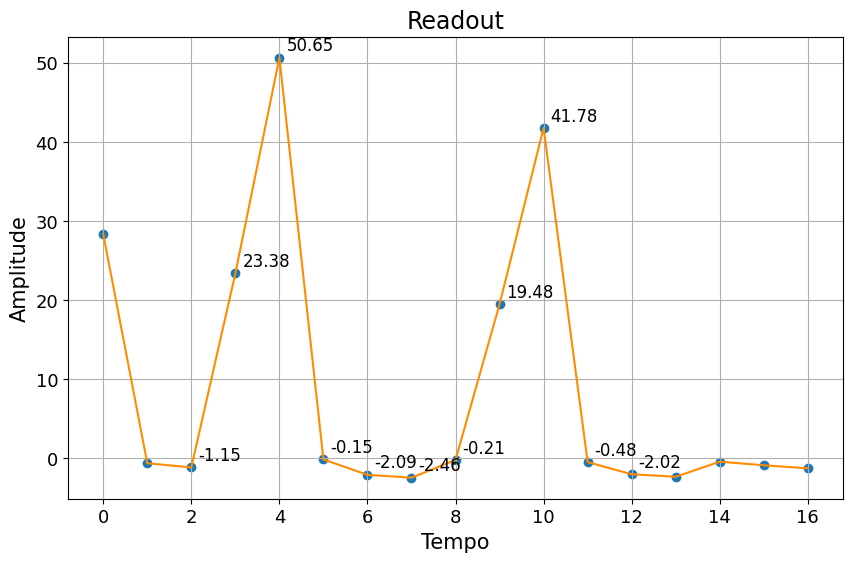

In [27]:
leitura_em_estudo_x = np.arange(len(leitura_em_estudo))

plt.plot(leitura_em_estudo, color="darkorange")
plt.scatter(leitura_em_estudo_x, leitura_em_estudo)
for xi, yi in zip(leitura_em_estudo_x, leitura_em_estudo):
    if not 1 < xi < 13:
        continue
    plt.annotate(
        f"{yi:.2f}",
        (xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=12,
    )

plt.title("Readout")
plt.xlabel("Tempo")
plt.ylabel("Amplitude")

In [28]:
2.09 / 50.65 * 100

4.126357354392892

# Wave former continua

In [ ]:
# Função de gerador de ondas
def wave_former_main_2(
    num_canais: int,
    qntd_amostras: int,
    CKT_parameters: Callable | None,
    CKT_simulator: Callable | None,
    noise: int | float | list | np.ndarray = 0,
    parameters: dict | None = None,
    Seed: int | None = None,
):

    # Parametros do CKT #
    TF, component, component_values = CKT_parameters()  # type: ignore[operator]

    # Parametros do gerador das formas de onda #
    if parameters is None:
        parametros_MC = {
            "iterations": num_canais,
            # "t": np.arange(0, qntd_amostras)  * 25 * 10**-9, # para sinal discreto
            "t": np.linspace(0, qntd_amostras) * 25 * 10**-9,  # para sinal continuo
            "FT": TF,  # literal
            "erro": noise,  # Erro de cada elemento do circuito
            "components": component,
            "nominal_values": component_values,
            "seed": Seed,
        }
    else:
        parametros_MC = parameters

    return CKT_simulator(**parametros_MC)  # type: ignore[operator]

In [ ]:
# Ondas/resp aos pulsos gerados

# cada linha é um canal
waves_por_canal2 = (
    np.asarray(  # waves_por_canal[0] = sinal sem variação dos componentes
        wave_former_main_2(
            num_canais=qntd_canais,
            qntd_amostras=qntd_canais,
            noise=ckt_parameters_error,
            CKT_parameters=ckt_parameters,
            CKT_simulator=MC_iteration,
            Seed=seed,
        )
    )
)

In [ ]:
leituras2 = {}
for (canal, amostras), wave in zip(s_originais.items(), waves_por_canal2):
    leituras2[canal] = [np.convolve(amostra, wave, mode="full") for amostra in amostras]

In [ ]:
leitura_em_estudo2 = leituras2["canal_0"][2]  # [86:103]
leitura_em_estudo_ordenada2 = sorted(leitura_em_estudo2, reverse=True)

pico1 = leitura_em_estudo_ordenada2[0]
pico2 = leitura_em_estudo_ordenada2[1]
vale1 = leitura_em_estudo_ordenada2[-1]
vale2 = leitura_em_estudo_ordenada2[-2]

print(
    f"{ pico1 = :.5f}\n",
    f"{pico2 = :.5f}\n",
    f"{vale1 = :.5f}\n",
    f"{vale2 = :.5f}\n",
)

In [ ]:
leitura_em_estudo_x2 = np.arange(len(leitura_em_estudo2))

plt.plot(leitura_em_estudo2, color="darkorange")
plt.scatter(leitura_em_estudo_x2, leitura_em_estudo2)
for xi, yi in zip(leitura_em_estudo_x2, leitura_em_estudo2):
    if not 1 < xi < 11:
        continue
    plt.annotate(
        f"{yi:.2f}",
        (xi, yi),
        xytext=(3, 3),
        textcoords="offset points",
        fontsize=12,
    )

plt.title("Readout")
plt.xlabel("Tempo")
plt.ylabel("Amplitude")